# Airbnb Price Classifier

Case Study: Predict whether an Airbnb listing will have a high price based on its rating and other features

Datasets: Airbnb Listings & Airbnb Reviews

Kaggle link: https://www.kaggle.com/datasets/mysarahmadbhat/airbnb-listings-reviews

In [31]:
# Import Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.stats import pearsonr, spearmanr
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score, make_scorer,  RocCurveDisplay


# Step 1: Data Cleaning and Datasets Merging. 

In [2]:
# Load datasets with alternate encoding
listings = pd.read_csv("Listings.csv", encoding="ISO-8859-1", low_memory=False)
reviews = pd.read_csv("Reviews.csv", encoding="ISO-8859-1", low_memory=False)

In [3]:
# Display basic info
print("Listings Dataset Info:")
listings.info()
listings.head()

Listings Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 279712 entries, 0 to 279711
Data columns (total 33 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   listing_id                   279712 non-null  int64  
 1   name                         279537 non-null  object 
 2   host_id                      279712 non-null  int64  
 3   host_since                   279547 non-null  object 
 4   host_location                278872 non-null  object 
 5   host_response_time           150930 non-null  object 
 6   host_response_rate           150930 non-null  float64
 7   host_acceptance_rate         166625 non-null  float64
 8   host_is_superhost            279547 non-null  object 
 9   host_total_listings_count    279547 non-null  float64
 10  host_has_profile_pic         279547 non-null  object 
 11  host_identity_verified       279547 non-null  object 
 12  neighbourhood                279712

,listing_id,name,host_id,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_total_listings_count,...,minimum_nights,maximum_nights,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable
0,281420,"Beautiful Flat in le Village Montmartre, Paris",1466919,2011-12-03,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
1,3705183,39 mÃÂ² Paris (Sacre CÃ âur),10328771,2013-11-29,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
2,4082273,"Lovely apartment with Terrace, 60m2",19252768,2014-07-31,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
3,4797344,Cosy studio (close to Eiffel tower),10668311,2013-12-17,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
4,4823489,Close to Eiffel Tower - Beautiful flat : 2 rooms,24837558,2014-12-14,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f


In [4]:
print("\nReviews Dataset Info:")
reviews.info()
reviews.head()


Reviews Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5373143 entries, 0 to 5373142
Data columns (total 4 columns):
 #   Column       Dtype 
---  ------       ----- 
 0   listing_id   int64 
 1   review_id    int64 
 2   date         object
 3   reviewer_id  int64 
dtypes: int64(3), object(1)
memory usage: 164.0+ MB


,listing_id,review_id,date,reviewer_id
0,11798,330265172,2018-09-30,11863072
1,15383,330103585,2018-09-30,39147453
2,16455,329985788,2018-09-30,1125378
3,17919,330016899,2018-09-30,172717984
4,26827,329995638,2018-09-30,17542859


Step 2: Clean and Merge datasets

In [5]:
# Check for missing values
print("\nMissing values in Listings dataset:")
print(listings.isnull().sum())

print("\nMissing values in Reviews dataset:")
print(reviews.isnull().sum())


Missing values in Listings dataset:
listing_id                          0
name                              175
host_id                             0
host_since                        165
host_location                     840
host_response_time             128782
host_response_rate             128782
host_acceptance_rate           113087
host_is_superhost                 165
host_total_listings_count         165
host_has_profile_pic              165
host_identity_verified            165
neighbourhood                       0
district                       242700
city                                0
latitude                            0
longitude                           0
property_type                       0
room_type                           0
accommodates                        0
bedrooms                        29435
amenities                           0
price                               0
minimum_nights                      0
maximum_nights                      0
review_scores

In [6]:
# Handle missing values

# Fill missing categorical values with a placeholder ("Unknown" or mode where applicable)
categorical_cols = ['host_response_time', 'host_is_superhost', 'host_identity_verified', 
                    'neighbourhood', 'city', 'property_type', 'room_type', 'instant_bookable']
for col in categorical_cols:
    listings[col] = listings[col].fillna("Unknown")

# Fill missing numerical values with the median of the column
numeric_cols = ['host_total_listings_count', 'accommodates', 'bedrooms', 'minimum_nights', 'maximum_nights']
for col in numeric_cols:
    listings[col] = listings[col].fillna(listings[col].median())

# Fill missing values for 'review_scores_rating' with the median (since it's important for the analysis)
listings['review_scores_rating'] = listings['review_scores_rating'].fillna(listings['review_scores_rating'].median())

# Remove rows with missing 'price' as it is the target variable (drop any rows where 'price' is missing)
listings = listings.dropna(subset=['price'])

# Convert target feature to catagorical 
# Convert price to numeric (remove currency symbols, convert to float)
listings['price'] = listings['price'].replace({'\$': '', ',': ''}, regex=True).astype(float)

# Calculate quartiles of price and assign categories
q1 = listings['price'].quantile(0.25)
q2 = listings['price'].quantile(0.50)  # Median
q3 = listings['price'].quantile(0.75)

# Assign categories based on quartiles
listings['price_category'] = pd.cut(listings['price'], bins=[0, q1, q2, q3, float('inf')], 
                                    labels=['Low', 'Medium', 'High', 'Very High'])

# Drop the original price column since we now use price_category
listings.drop(columns=['price'], inplace=True)

# Optional: Drop 'district' column as it has too many missing values
listings.drop(columns=['district'], inplace=True, errors='ignore')

# Optional: Drop 'name' column if it has too many missing values (or impute as needed)
listings.drop(columns=['name'], inplace=True, errors='ignore')

# Verify dataset after cleaning
print("\nListings dataset after cleaning:")
listings.info()
listings.head()



Listings dataset after cleaning:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 279712 entries, 0 to 279711
Data columns (total 31 columns):
 #   Column                       Non-Null Count   Dtype   
---  ------                       --------------   -----   
 0   listing_id                   279712 non-null  int64   
 1   host_id                      279712 non-null  int64   
 2   host_since                   279547 non-null  object  
 3   host_location                278872 non-null  object  
 4   host_response_time           279712 non-null  object  
 5   host_response_rate           150930 non-null  float64 
 6   host_acceptance_rate         166625 non-null  float64 
 7   host_is_superhost            279712 non-null  object  
 8   host_total_listings_count    279712 non-null  float64 
 9   host_has_profile_pic         279547 non-null  object  
 10  host_identity_verified       279712 non-null  object  
 11  neighbourhood                279712 non-null  object  
 12  city      

,listing_id,host_id,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_total_listings_count,host_has_profile_pic,...,maximum_nights,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,price_category
0,281420,1466919,2011-12-03,"Paris, Ile-de-France, France",Unknown,NaN,NaN,f,1.0,t,...,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f,Low
1,3705183,10328771,2013-11-29,"Paris, Ile-de-France, France",Unknown,NaN,NaN,f,1.0,t,...,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f,Medium
2,4082273,19252768,2014-07-31,"Paris, Ile-de-France, France",Unknown,NaN,NaN,f,1.0,t,...,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f,Medium
3,4797344,10668311,2013-12-17,"Paris, Ile-de-France, France",Unknown,NaN,NaN,f,1.0,t,...,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f,Low
4,4823489,24837558,2014-12-14,"Paris, Ile-de-France, France",Unknown,NaN,NaN,f,1.0,t,...,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f,Low


In [7]:
# Data Merging

# Ensure the 'listing_id' column exists in both datasets
if 'listing_id' in listings.columns and 'listing_id' in reviews.columns:
    
    # Convert 'date' to datetime in the reviews dataset
    reviews['date'] = pd.to_datetime(reviews['date'])
    
    # Count total reviews per listing
    review_counts = reviews.groupby('listing_id').size().reset_index(name='review_count')
    
    # Count number of months a listing received reviews
    reviews['year_month'] = reviews['date'].dt.to_period('M')  
    review_trend = reviews.groupby('listing_id')['year_month'].nunique().reset_index()
    review_trend.rename(columns={'year_month': 'review_months_active'}, inplace=True)
    
    # Count number of recent reviews (last 6 months) (need to create review count from the past 6 month of every observations)
    latest_date = reviews['date'].max()
    six_months_ago = latest_date - pd.DateOffset(months=6)
    recent_reviews = reviews[reviews['date'] >= six_months_ago].groupby('listing_id').size().reset_index(name='recent_review_count')
    
    # Merge all review-based features with the listings dataset
    merged_df = listings.merge(review_counts, on='listing_id', how='left')
    merged_df = merged_df.merge(review_trend, on='listing_id', how='left')
    merged_df = merged_df.merge(recent_reviews, on='listing_id', how='left')
    
    # Fill NaN values (listings with no reviews)
    merged_df[['review_count', 'review_months_active', 'recent_review_count']] = merged_df[['review_count', 'review_months_active', 'recent_review_count']].fillna(0)
    
    # Final merged dataset info
    print("\nFinal Merged Dataset Info:")
    merged_df.info()
    merged_df.head()

else:
    print("\n'listing_id' column is not found in both datasets. Please check the column names.")



Final Merged Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 279712 entries, 0 to 279711
Data columns (total 34 columns):
 #   Column                       Non-Null Count   Dtype   
---  ------                       --------------   -----   
 0   listing_id                   279712 non-null  int64   
 1   host_id                      279712 non-null  int64   
 2   host_since                   279547 non-null  object  
 3   host_location                278872 non-null  object  
 4   host_response_time           279712 non-null  object  
 5   host_response_rate           150930 non-null  float64 
 6   host_acceptance_rate         166625 non-null  float64 
 7   host_is_superhost            279712 non-null  object  
 8   host_total_listings_count    279712 non-null  float64 
 9   host_has_profile_pic         279547 non-null  object  
 10  host_identity_verified       279712 non-null  object  
 11  neighbourhood                279712 non-null  object  
 12  city            

In [8]:
merged_df.head()

,listing_id,host_id,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_total_listings_count,host_has_profile_pic,...,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,price_category,review_count,review_months_active,recent_review_count
0,281420,1466919,2011-12-03,"Paris, Ile-de-France, France",Unknown,NaN,NaN,f,1.0,t,...,10.0,10.0,10.0,10.0,10.0,f,Low,2.0,1.0,0.0
1,3705183,10328771,2013-11-29,"Paris, Ile-de-France, France",Unknown,NaN,NaN,f,1.0,t,...,10.0,10.0,10.0,10.0,10.0,f,Medium,6.0,5.0,0.0
2,4082273,19252768,2014-07-31,"Paris, Ile-de-France, France",Unknown,NaN,NaN,f,1.0,t,...,10.0,10.0,10.0,10.0,10.0,f,Medium,1.0,1.0,0.0
3,4797344,10668311,2013-12-17,"Paris, Ile-de-France, France",Unknown,NaN,NaN,f,1.0,t,...,10.0,10.0,10.0,10.0,10.0,f,Low,1.0,1.0,0.0
4,4823489,24837558,2014-12-14,"Paris, Ile-de-France, France",Unknown,NaN,NaN,f,1.0,t,...,10.0,10.0,10.0,10.0,10.0,f,Low,1.0,1.0,0.0


In [9]:
# Check missing values in the merged dataset
missing_values = merged_df.isnull().sum()
print("\nMissing Values:")
print(missing_values[missing_values > 0])


Missing Values:
host_since                        165
host_location                     840
host_response_rate             128782
host_acceptance_rate           113087
host_has_profile_pic              165
review_scores_accuracy          91713
review_scores_cleanliness       91665
review_scores_checkin           91771
review_scores_communication     91687
review_scores_location          91775
review_scores_value             91785
price_category                    113
dtype: int64


In [10]:
# Fill missing categorical values with "Unknown" or mode
categorical_cols_with_missing = ['host_location', 'host_has_profile_pic']
for col in categorical_cols_with_missing:
    merged_df[col] = merged_df[col].fillna("Unknown")

# Fill missing numeric values with the median
numeric_cols_with_missing = ['host_response_rate', 'host_acceptance_rate', 'review_scores_accuracy', 
                             'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 
                             'review_scores_location', 'review_scores_value']
for col in numeric_cols_with_missing:
    merged_df[col] = merged_df[col].fillna(merged_df[col].median())

# Drop columns with too many missing values
merged_df.drop(columns=['host_response_rate', 'review_scores_accuracy', 'review_scores_cleanliness', 
                        'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 
                        'review_scores_value'], inplace=True, errors='ignore')

# Final check for missing values
missing_values = merged_df.isnull().sum()
print("\nMissing Values After Handling:")
print(missing_values[missing_values > 0])

# Check the updated dataset information
print("\nUpdated Dataset Info After Missing Value Handling:")
print(merged_df.info())



Missing Values After Handling:
host_since        165
price_category    113
dtype: int64

Updated Dataset Info After Missing Value Handling:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 279712 entries, 0 to 279711
Data columns (total 27 columns):
 #   Column                     Non-Null Count   Dtype   
---  ------                     --------------   -----   
 0   listing_id                 279712 non-null  int64   
 1   host_id                    279712 non-null  int64   
 2   host_since                 279547 non-null  object  
 3   host_location              279712 non-null  object  
 4   host_response_time         279712 non-null  object  
 5   host_acceptance_rate       279712 non-null  float64 
 6   host_is_superhost          279712 non-null  object  
 7   host_total_listings_count  279712 non-null  float64 
 8   host_has_profile_pic       279712 non-null  object  
 9   host_identity_verified     279712 non-null  object  
 10  neighbourhood              279712 non-null  obj

In [11]:
# Convert 'host_since' to datetime (if not already)
merged_df['host_since'] = pd.to_datetime(merged_df['host_since'], errors='coerce')

# Fill missing 'host_since' values with the earliest date
earliest_date = merged_df['host_since'].min()
merged_df['host_since'] = merged_df['host_since'].fillna(earliest_date)

# Convert 'host_since' to the number of days since the earliest date
merged_df['host_since'] = (merged_df['host_since'] - earliest_date).dt.days

# Drop rows with missing values in 'price_category' (target variable)
merged_df.dropna(subset=['price_category'], inplace=True)

# Check for any remaining missing values
missing_values = merged_df.isnull().sum()
print("\nMissing Values after Imputation:")
print(missing_values[missing_values > 0])


Missing Values after Imputation:
Series([], dtype: int64)


In [12]:
# Drop irrelevant columns
columns_to_drop = [
    'listing_id', 'host_id',  # Unique identifiers, not useful for prediction
    'host_location', 'host_response_rate', 'host_acceptance_rate', 'host_has_profile_pic'  # Too many missing values
]

merged_df.drop(columns=columns_to_drop, inplace=True, errors='ignore')

# Check dataset after dropping irrelevant columns
print("\nDataset after dropping irrelevant columns:")
merged_df.info()


Dataset after dropping irrelevant columns:
<class 'pandas.core.frame.DataFrame'>
Index: 279599 entries, 0 to 279711
Data columns (total 22 columns):
 #   Column                     Non-Null Count   Dtype   
---  ------                     --------------   -----   
 0   host_since                 279599 non-null  int64   
 1   host_response_time         279599 non-null  object  
 2   host_is_superhost          279599 non-null  object  
 3   host_total_listings_count  279599 non-null  float64 
 4   host_identity_verified     279599 non-null  object  
 5   neighbourhood              279599 non-null  object  
 6   city                       279599 non-null  object  
 7   latitude                   279599 non-null  float64 
 8   longitude                  279599 non-null  float64 
 9   property_type              279599 non-null  object  
 10  room_type                  279599 non-null  object  
 11  accommodates               279599 non-null  int64   
 12  bedrooms                   279599

In [13]:
# Drop 'host_since' if it is constant
if merged_df["host_since"].nunique() == 1:
    merged_df.drop(columns=["host_since"], inplace=True)
    print("'host_since' was dropped as it is a constant feature.")
else:
    print("'host_since' has more than one unique value and was not dropped.")

'host_since' has more than one unique value and was not dropped.


# Step 2: Feature Selection and Correlation Analysis (with Visualisation). 


Categorical Feature Correlations with 'price_category':
                  Feature  Correlation                      Type
3           neighbourhood     0.539234  Categorical (Cramér’s V)
4                    city     0.499064  Categorical (Cramér’s V)
5           property_type     0.237181  Categorical (Cramér’s V)
6               room_type     0.121762  Categorical (Cramér’s V)
0      host_response_time     0.110485  Categorical (Cramér’s V)
7        instant_bookable     0.079585  Categorical (Cramér’s V)
2  host_identity_verified     0.046635  Categorical (Cramér’s V)
1       host_is_superhost     0.044190  Categorical (Cramér’s V)


C:\Users\aiden\AppData\Local\Temp\ipykernel_2044\3639208101.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Correlation', y='Feature', data=categorical_df, palette='viridis')


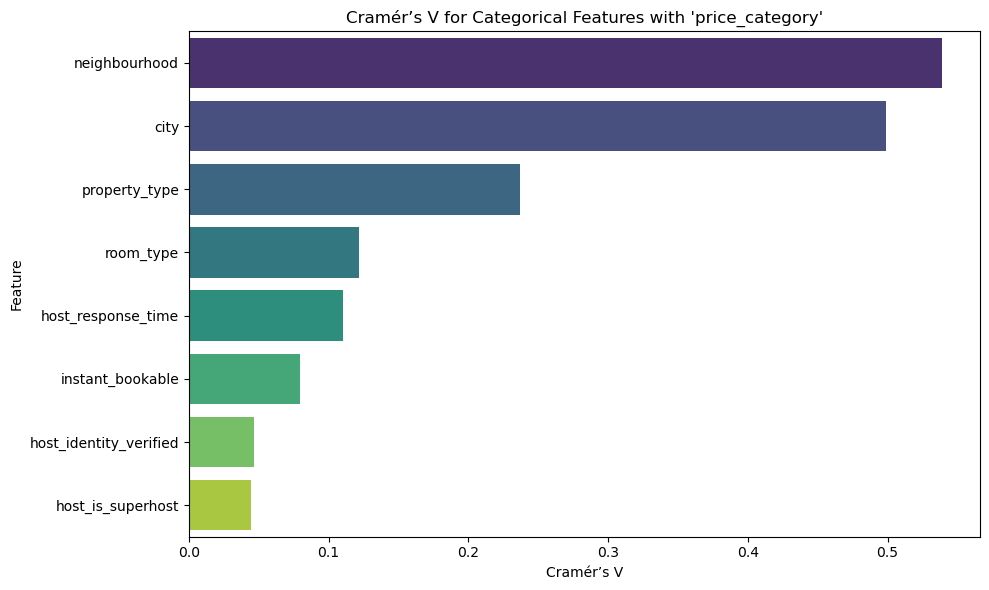

In [14]:
# Define categorical columns
categorical_columns = [
    'host_response_time', 'host_is_superhost', 'host_identity_verified', 
    'neighbourhood', 'city', 'property_type', 'room_type', 'instant_bookable'
]

# Calculating Cramér’s V
def cramers_v(confusion_matrix):
    chi2, p_val, dof, expected = stats.chi2_contingency(confusion_matrix)
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    return np.sqrt(phi2 / min((k-1), (r-1)))

# Recompute Cramér’s V for categorical features
categorical_correlations = {}
for col in categorical_columns:
    contingency_table = pd.crosstab(merged_df[col], merged_df['price_category'])
    categorical_correlations[col] = cramers_v(contingency_table)

# Create a DataFrame for categorical correlations
categorical_df = pd.DataFrame({
    'Feature': list(categorical_correlations.keys()),
    'Correlation': list(categorical_correlations.values()),
    'Type': 'Categorical (Cramér’s V)'
})

# Sort by correlation values
categorical_df = categorical_df.sort_values(by='Correlation', ascending=False)

# Display the results
print("\nCategorical Feature Correlations with 'price_category':")
print(categorical_df)

plt.figure(figsize=(10, 6))
sns.barplot(x='Correlation', y='Feature', data=categorical_df, palette='viridis')
plt.title("Cramér’s V for Categorical Features with 'price_category'")
plt.xlabel("Cramér’s V")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

Numerical Feature Correlations with 'price_category':
                      Feature  Mutual Information  Pearson Correlation  \
0                   longitude            0.463258             0.043636   
1                    latitude            0.408757            -0.387048   
2                    bedrooms            0.075374             0.266924   
3                accommodates            0.073772             0.316900   
4   host_total_listings_count            0.056096             0.044669   
5              minimum_nights            0.019352            -0.024740   
6        review_scores_rating            0.013726             0.057401   
7              maximum_nights            0.012059            -0.000209   
8        review_months_active            0.009811            -0.072927   
9                review_count            0.008856            -0.079605   
10        recent_review_count            0.003037             0.027071   

    Spearman Correlation  
0               0.091632  
1  

C:\Users\aiden\AppData\Local\Temp\ipykernel_2044\1741174977.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Mutual Information", y="Feature", data=numerical_results, ax=axes[0], palette="viridis")
C:\Users\aiden\AppData\Local\Temp\ipykernel_2044\1741174977.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Pearson Correlation", y="Feature", data=numerical_results, ax=axes[1], palette="viridis")
C:\Users\aiden\AppData\Local\Temp\ipykernel_2044\1741174977.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Spearman Correlation

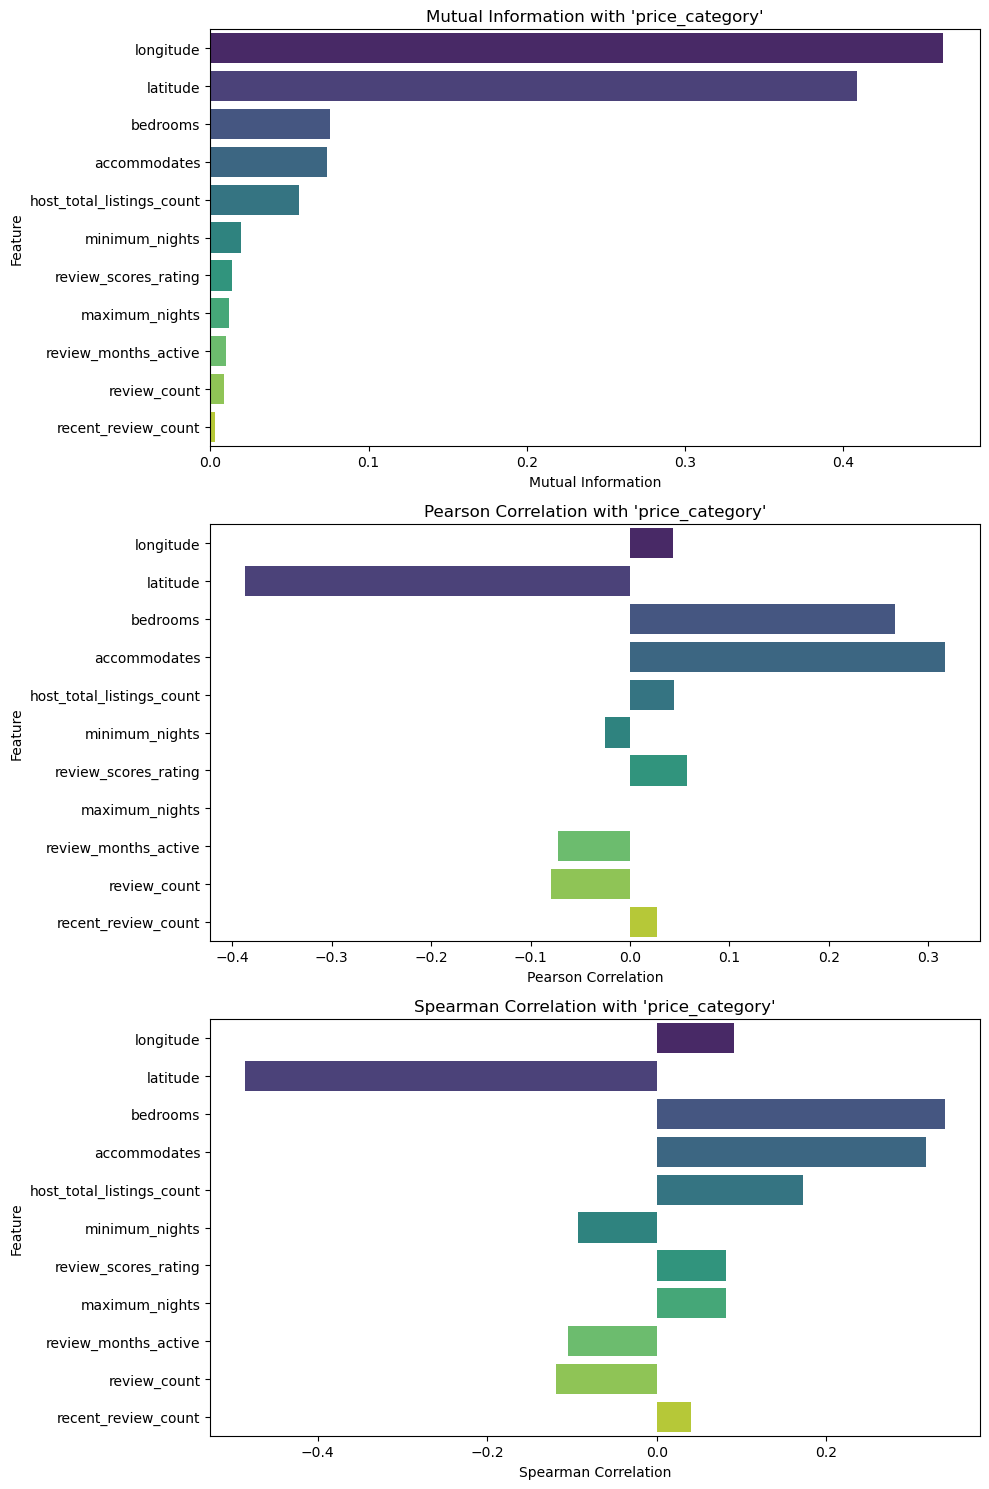

In [15]:
# Define numerical columns
numerical_columns = ['host_total_listings_count', 'latitude', 'longitude', 'accommodates', 'bedrooms', 'minimum_nights', 'maximum_nights', 'review_scores_rating', 'review_count', 'review_months_active', 'recent_review_count']  # Replace with your actual numerical columns

# Ensure 'price_category' is numerical (if it's categorical, encode it)
merged_df['price_category'] = merged_df['price_category'].astype('category').cat.codes

# Function to compute mutual information
def compute_mutual_info(X, y):
    mi_scores = mutual_info_classif(X, y, random_state=42)
    mi_df = pd.DataFrame({'Feature': X.columns, 'Mutual Information': mi_scores})
    return mi_df.sort_values(by='Mutual Information', ascending=False)

# Function to compute Pearson and Spearman correlations
def compute_correlation(X, y):
    pearson_corr = []
    spearman_corr = []
    for col in X.columns:
        pearson_corr.append(pearsonr(X[col], y)[0])
        spearman_corr.append(spearmanr(X[col], y)[0])
    corr_df = pd.DataFrame({
        'Feature': X.columns,
        'Pearson Correlation': pearson_corr,
        'Spearman Correlation': spearman_corr
    })
    return corr_df.sort_values(by='Pearson Correlation', ascending=False)

# Compute mutual information
mi_scores = compute_mutual_info(merged_df[numerical_columns], merged_df['price_category'])

# Compute Pearson and Spearman correlations
correlation_scores = compute_correlation(merged_df[numerical_columns], merged_df['price_category'])

# Combine results into a single DataFrame
numerical_results = pd.merge(mi_scores, correlation_scores, on="Feature")

# Print the DataFrame of correlations
print("Numerical Feature Correlations with 'price_category':")
print(numerical_results)

# Set up the figure and axes
fig, axes = plt.subplots(3, 1, figsize=(10, 15))

# Plot Mutual Information
sns.barplot(x="Mutual Information", y="Feature", data=numerical_results, ax=axes[0], palette="viridis")
axes[0].set_title("Mutual Information with 'price_category'")
axes[0].set_xlabel("Mutual Information")
axes[0].set_ylabel("Feature")

# Plot Pearson Correlation
sns.barplot(x="Pearson Correlation", y="Feature", data=numerical_results, ax=axes[1], palette="viridis")
axes[1].set_title("Pearson Correlation with 'price_category'")
axes[1].set_xlabel("Pearson Correlation")
axes[1].set_ylabel("Feature")

# Plot Spearman Correlation
sns.barplot(x="Spearman Correlation", y="Feature", data=numerical_results, ax=axes[2], palette="viridis")
axes[2].set_title("Spearman Correlation with 'price_category'")
axes[2].set_xlabel("Spearman Correlation")
axes[2].set_ylabel("Feature")

# Adjust layout and display the plots
plt.tight_layout()
plt.show()

# Step 3: Model Building (Logistic Regression, SVM and Naïve Bayes).

In [16]:
# Step 1: Prepare the data
# Separate features (X) and target (y)
X = merged_df.drop(columns=['price_category'])
y = merged_df['price_category']

# Step 2: Reduce the dataset to 10% of its original size (stratified by y)
X_reduced, _, y_reduced, _ = train_test_split(X, y, test_size=0.90, random_state=42, stratify=y)

# Step 3: Split the reduced data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_reduced, y_reduced, test_size=0.2, random_state=42, stratify=y_reduced)

# Step 4: Preprocessing
# Define numerical and categorical features
numerical_features = numerical_columns  # From Step 2
categorical_features = categorical_columns  # From Step 2

# Create a ColumnTransformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ])

# Step 5: Define the models
models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "SVM": SVC(random_state=42, probability=True),  # Enable probability for evaluation
    "Naive Bayes": GaussianNB()
}

# Step 6: Train and evaluate the models
results = {}
for model_name, model in models.items():
    # Create a pipeline with preprocessing and the model
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    # Train the model
    pipeline.fit(X_train, y_train)
    
    # Make predictions
    y_pred = pipeline.predict(X_test)
    
    # Evaluate the model
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    # Store the results
    results[model_name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1
    }
    
    # Print classification report and confusion matrix
    print(f"--- {model_name} ---")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\n")

# Step 7: Compare the models
results_df = pd.DataFrame(results).T
print("Model Performance Comparison:")
print(results_df)

--- Logistic Regression ---
Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.79      0.75      1418
           1       0.56      0.56      0.56      1416
           2       0.60      0.58      0.59      1359
           3       0.83      0.78      0.80      1399

    accuracy                           0.68      5592
   macro avg       0.68      0.68      0.68      5592
weighted avg       0.68      0.68      0.68      5592

Confusion Matrix:
[[1118  270   29    1]
 [ 388  789  225   14]
 [  33  321  790  215]
 [  10   35  268 1086]]


--- SVM ---
Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.82      0.76      1418
           1       0.56      0.53      0.54      1416
           2       0.60      0.60      0.60      1359
           3       0.86      0.76      0.81      1399

    accuracy                           0.68      5592
   macro avg       0.68      0.68      0

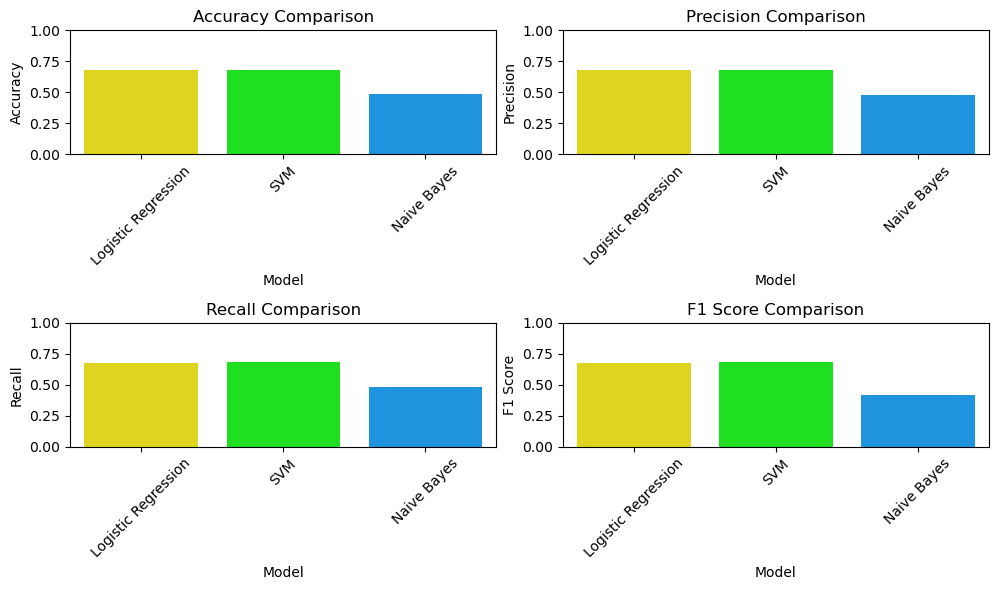

In [28]:
# Model performance results
results = {
    'Model': ['Logistic Regression', 'SVM', 'Naive Bayes'],
    'Accuracy': [0.676502, 0.680436, 0.482833],
    'Precision': [0.677003, 0.683042, 0.479178],
    'Recall': [0.676502, 0.680436, 0.482833],
    'F1 Score': [0.676148, 0.679791, 0.415632]
}

# Convert to DataFrame
results_df = pd.DataFrame(results)

# Define custom colors for models
colors = {'Logistic Regression': '#FFF000',  # Yellow
          'SVM': '#00FF00',  # Green
          'Naive Bayes': '#0099FF'}  # Blue

# Set up the plot
plt.figure(figsize=(10, 6))

# Plot each metric
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
for i, metric in enumerate(metrics):
    plt.subplot(2, 2, i + 1)
    ax = sns.barplot(x='Model', y=metric, hue='Model', data=results_df, palette=colors, legend=False)
    plt.title(f'{metric} Comparison')
    plt.ylim(0, 1)  # Set y-axis limit to 0-1 for better visualization
    plt.xticks(rotation=45)  # Rotate x-axis labels for readability

# Adjust layout
plt.tight_layout()
plt.show()

Analysis of Results

1. Overall Performance
- Logistic Regression and SVM perform similarly, with SVM slightly outperforming Logistic Regression in all metrics.
- Naive Bayes performs significantly worse than the other two models, with much lower accuracy, precision, recall, and F1 score.

2. Accuracy
- SVM has the highest accuracy (0.6804), followed by Logistic Regression (0.6765).
- Naive Bayes has the lowest accuracy (0.4828), which is close to random guessing (0.5 for a binary classification problem).

3. Precision
- SVM has the highest precision (0.6830), meaning it has the lowest rate of false positives.
- Naive Bayes has the lowest precision (0.4792), indicating a high rate of false positives.

4. Recall
- SVM also has the highest recall (0.6804), meaning it has the lowest rate of false negatives.
- Naive Bayes has the lowest recall (0.4828), indicating a high rate of false negatives.

5. F1 Score
- The F1 score (harmonic mean of precision and recall) is highest for SVM (0.6798), followed by Logistic Regression (0.6761).
- Naive Bayes has the lowest F1 score (0.4156), which is significantly worse than the other models.

Key Observations

1. SVM is the Best Performing Model:
- SVM has the highest accuracy, precision, recall, and F1 score.
- However, SVM is computationally expensive, especially for large datasets. If training time is a concern, Logistic Regression might be a better choice due to its similar performance.

2. Logistic Regression is a Close Second:
- Logistic Regression performs almost as well as SVM but is faster to train.
- It is a good choice if you need a balance between performance and computational efficiency.

3. Naive Bayes Performs Poorly:
- Naive Bayes has the worst performance across all metrics.
- This could be due to the assumption of feature independence, which might not hold true for your dataset.

# Step 4: Hyperparameter Tuning (Hyperparameter Tuning with AUC/ROC)

Best Parameters for SVM: {'model__kernel': 'linear', 'model__gamma': 'scale', 'model__C': 0.1}
Best Cross-Validation AUC for SVM: 0.8553280858328373
Best Parameters for Logistic Regression: {'model__solver': 'liblinear', 'model__penalty': 'l2', 'model__C': 1}
Best Cross-Validation AUC for Logistic Regression: 0.8569157100565796
SVM Predict Proba Shape: (1678, 4)
Logistic Regression Predict Proba Shape: (1678, 4)
Test Set AUC for SVM: 0.8770186677551732
Test Set AUC for Logistic Regression: 0.8762633403352538


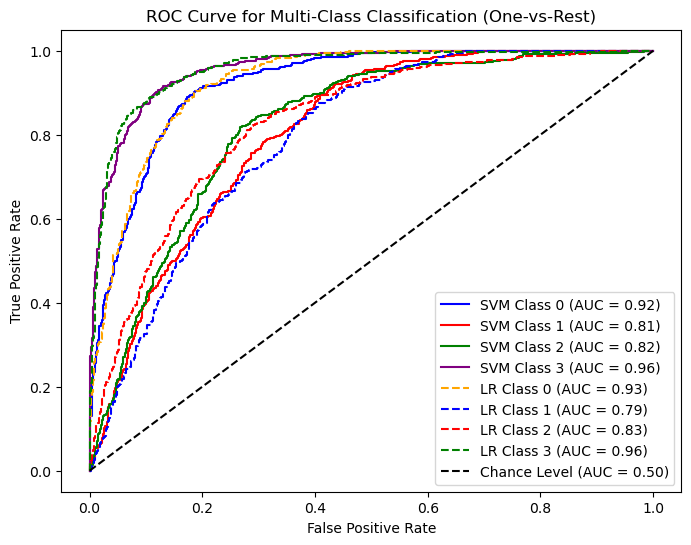

In [41]:
import warnings
from sklearn.metrics import roc_curve, auc
from itertools import cycle

# Ignore warnings
warnings.filterwarnings('ignore')

# Define numerical and categorical features
numerical_columns = [
    'host_total_listings_count', 'latitude', 'longitude', 
    'accommodates', 'bedrooms', 'minimum_nights', 'maximum_nights', 
    'review_scores_rating', 'review_count', 'review_months_active', 
    'recent_review_count'
]

categorical_columns = [
    'host_response_time', 'host_is_superhost', 'host_identity_verified', 
    'neighbourhood', 'city', 'property_type', 'room_type', 'instant_bookable'
]

# Separate features (X) and target (y)
X = merged_df.drop(columns=['price_category'])  # Assuming merged_df exists
y = merged_df['price_category']

# Step 1: Reduce dataset to 3% of its original size (stratified by y)
X_reduced, _, y_reduced, _ = train_test_split(X, y, test_size=0.97, random_state=42, stratify=y)

# Step 2: Split reduced data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_reduced, y_reduced, test_size=0.2, random_state=42, stratify=y_reduced)

# Step 3: Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_columns),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_columns)
    ]
)

# Step 4: Define the parameter grid for SVM
param_grid_svm = {
    'model__C': [0.1, 1, 10],
    'model__kernel': ['linear', 'rbf'],
    'model__gamma': ['scale']
}

# Create SVM pipeline
pipeline_svm = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', SVC(random_state=42, probability=True))  # Enable probability for AUC calculation
])

# Use AUC/ROC as the scoring metric
roc_auc_scorer = make_scorer(roc_auc_score, response_method='predict_proba', multi_class='ovr')

# Step 5: Further reduce sample size for SVM (2000 rows)
X_train_svm, _, y_train_svm, _ = train_test_split(X_train, y_train, train_size=2000, random_state=42, stratify=y_train)

# Perform Randomized Search for SVM
random_search_svm = RandomizedSearchCV(
    pipeline_svm, 
    param_grid_svm, 
    n_iter=4,  
    cv=3,  
    scoring=roc_auc_scorer, 
    n_jobs=-1,  
    random_state=42,
    error_score='raise'  
)
random_search_svm.fit(X_train_svm, y_train_svm)

# Print best parameters and score for SVM
print("Best Parameters for SVM:", random_search_svm.best_params_)
print("Best Cross-Validation AUC for SVM:", random_search_svm.best_score_)

# Step 6: Define the parameter grid for Logistic Regression
param_grid_lr = {
    'model__C': [0.01, 0.1, 1],
    'model__penalty': ['l2'],
    'model__solver': ['liblinear']
}

# Create Logistic Regression pipeline
pipeline_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(random_state=42, max_iter=1000))
])

# Perform Randomized Search for Logistic Regression
random_search_lr = RandomizedSearchCV(
    pipeline_lr, 
    param_grid_lr, 
    n_iter=3,  # Fixed: Reduced to match available parameters
    cv=3,  
    scoring=roc_auc_scorer, 
    n_jobs=-1,  
    random_state=42,
    error_score='raise'  
)
random_search_lr.fit(X_train, y_train)

# Print best parameters and score for Logistic Regression
print("Best Parameters for Logistic Regression:", random_search_lr.best_params_)
print("Best Cross-Validation AUC for Logistic Regression:", random_search_lr.best_score_)

# Step 7: Predict probabilities directly from the best estimators
y_pred_proba_svm = random_search_svm.best_estimator_.predict_proba(X_test)
y_pred_proba_lr = random_search_lr.best_estimator_.predict_proba(X_test)

# Debugging: Check shape
print("SVM Predict Proba Shape:", y_pred_proba_svm.shape)
print("Logistic Regression Predict Proba Shape:", y_pred_proba_lr.shape)

# Compute AUC for SVM and Logistic Regression
test_auc_svm = roc_auc_score(y_test, y_pred_proba_svm, multi_class='ovr')
test_auc_lr = roc_auc_score(y_test, y_pred_proba_lr, multi_class='ovr')

print("Test Set AUC for SVM:", test_auc_svm)
print("Test Set AUC for Logistic Regression:", test_auc_lr)

# Define colors for each class
colors = cycle(['blue', 'red', 'green', 'purple', 'orange'])

# Number of classes
n_classes = len(np.unique(y_test))

# Plot ROC Curve for each class
plt.figure(figsize=(8, 6))

for i, color in zip(range(n_classes), colors):
    fpr, tpr, _ = roc_curve(y_test == i, y_pred_proba_svm[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, label=f'SVM Class {i} (AUC = {roc_auc:.2f})')

for i, color in zip(range(n_classes), colors):
    fpr, tpr, _ = roc_curve(y_test == i, y_pred_proba_lr[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, '--', color=color, label=f'LR Class {i} (AUC = {roc_auc:.2f})')

# Plot Chance Line
plt.plot([0, 1], [0, 1], 'k--', label="Chance Level (AUC = 0.50)")

# Formatting
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Multi-Class Classification (One-vs-Rest)")
plt.legend()
plt.show()

Best Parameters:
- SVM: Uses a linear kernel with C=0.1 and gamma=scale.
- Logistic Regression: Uses solver=liblinear, penalty=l2, and C=1.

Cross-Validation AUC:
- SVM AUC: 0.8553
- Logistic Regression AUC: 0.8569

The Logistic Regression model performs slightly better in cross-validation, though the difference is small.

Predicted Probability Shape:
- Both models predict probabilities for 4 classes on 1678 test samples.
    
Test Set AUC:
- SVM AUC: 0.8770
- Logistic Regression AUC: 0.8763

Both models perform very well on the test set, with SVM achieving a marginally higher AUC.
    
Summary:
Overall, both SVM and Logistic Regression provide strong performance with high AUC scores, indicating that they are both suitable for this classification task. The slight edge in AUC for SVM suggests it might be a slightly better choice, but the performance difference is minimal, so either model could work well in practice.


# Step 5: Final Model Testing

Using SVM to compare all-features model vs 5-highest-correlated features model. 

In [34]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix


# Step 1: Prepare the data
# Separate features (X) and target (y)
X = merged_df.drop(columns=['price_category'])
y = merged_df['price_category']

# Step 2: Reduce the dataset to 2000 rows (stratified by y)
X_reduced, _, y_reduced, _ = train_test_split(X, y, train_size=2000, random_state=40, stratify=y)

# Step 3: Split the reduced data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_reduced, y_reduced, test_size=0.2, random_state=40, stratify=y_reduced)

# Step 4: Define the highest-correlated features
highest_correlated_features = ['neighbourhood', 'city', 'property_type', 'bedrooms', 'accommodates']

# Create a reduced feature set
X_train_reduced = X_train[highest_correlated_features]
X_test_reduced = X_test[highest_correlated_features]

# Step 5: Preprocessing
# Define numerical and categorical features for the full and reduced feature sets
numerical_features_full = numerical_columns  # From Step 3
categorical_features_full = categorical_columns  # From Step 3

numerical_features_reduced = ['bedrooms', 'accommodates']
categorical_features_reduced = ['neighbourhood', 'city', 'property_type']

# Create a ColumnTransformer for preprocessing the full feature set
preprocessor_full = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features_full),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features_full)
    ])

# Create a ColumnTransformer for preprocessing the reduced feature set
preprocessor_reduced = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features_reduced),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features_reduced)
    ])

# Step 6: Train and evaluate the SVM model with the full feature set
svm_full = Pipeline(steps=[
    ('preprocessor', preprocessor_full),
    ('model', SVC(random_state=42, probability=True))
])

svm_full.fit(X_train, y_train)
y_pred_full = svm_full.predict(X_test)

# Evaluate the full feature set model
accuracy_full = accuracy_score(y_test, y_pred_full)
precision_full = precision_score(y_test, y_pred_full, average='weighted')
recall_full = recall_score(y_test, y_pred_full, average='weighted')
f1_full = f1_score(y_test, y_pred_full, average='weighted')

print("--- SVM with Full Feature Set ---")
print("Classification Report:")
print(classification_report(y_test, y_pred_full))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_full))
print(f"Accuracy: {accuracy_full}")
print(f"Precision: {precision_full}")
print(f"Recall: {recall_full}")
print(f"F1 Score: {f1_full}")
print("\n")

# Step 7: Train and evaluate the SVM model with the reduced feature set
svm_reduced = Pipeline(steps=[
    ('preprocessor', preprocessor_reduced),
    ('model', SVC(random_state=42, probability=True))
])

svm_reduced.fit(X_train_reduced, y_train)
y_pred_reduced = svm_reduced.predict(X_test_reduced)

# Evaluate the reduced feature set model
accuracy_reduced = accuracy_score(y_test, y_pred_reduced)
precision_reduced = precision_score(y_test, y_pred_reduced, average='weighted')
recall_reduced = recall_score(y_test, y_pred_reduced, average='weighted')
f1_reduced = f1_score(y_test, y_pred_reduced, average='weighted')

print("--- SVM with Reduced Feature Set ---")
print("Classification Report:")
print(classification_report(y_test, y_pred_reduced))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_reduced))
print(f"Accuracy: {accuracy_reduced}")
print(f"Precision: {precision_reduced}")
print(f"Recall: {recall_reduced}")
print(f"F1 Score: {f1_reduced}")
print("\n")

# Step 8: Compare the results
results = {
    "SVM (Full Features)": {
        'Accuracy': accuracy_full,
        'Precision': precision_full,
        'Recall': recall_full,
        'F1 Score': f1_full
    },
    "SVM (Reduced Features)": {
        'Accuracy': accuracy_reduced,
        'Precision': precision_reduced,
        'Recall': recall_reduced,
        'F1 Score': f1_reduced
    }
}

results_df = pd.DataFrame(results).T
print("Model Performance Comparison:")
print(results_df)

--- SVM with Full Feature Set ---
Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.66      0.66       102
           1       0.44      0.45      0.44       101
           2       0.50      0.54      0.52        97
           3       0.79      0.73      0.76       100

    accuracy                           0.59       400
   macro avg       0.60      0.59      0.59       400
weighted avg       0.60      0.59      0.60       400

Confusion Matrix:
[[67 31  4  0]
 [25 45 28  3]
 [ 5 24 52 16]
 [ 4  3 20 73]]
Accuracy: 0.5925
Precision: 0.599093515039558
Recall: 0.5925
F1 Score: 0.5952989854588258


--- SVM with Reduced Feature Set ---
Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.75      0.73       102
           1       0.51      0.51      0.51       101
           2       0.50      0.52      0.51        97
           3       0.79      0.73      0.76       100

    a

In [18]:
# Hyperparmeter Tuning applied

# Step 1: Prepare the data
# Separate features (X) and target (y)
X = merged_df.drop(columns=['price_category'])
y = merged_df['price_category']

# Step 2: Reduce the dataset to 2000 rows (stratified by y)
X_reduced, _, y_reduced, _ = train_test_split(X, y, train_size=2000, random_state=42, stratify=y)

# Step 3: Split the reduced data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_reduced, y_reduced, test_size=0.2, random_state=42, stratify=y_reduced)

# Step 4: Define the highest-correlated features
highest_correlated_features = ['neighbourhood', 'city', 'property_type', 'bedrooms', 'accommodates']

# Create a reduced feature set
X_train_reduced = X_train[highest_correlated_features]
X_test_reduced = X_test[highest_correlated_features]

# Step 5: Preprocessing
# Define numerical and categorical features for the full and reduced feature sets
numerical_features_full = numerical_columns  # From Step 3
categorical_features_full = categorical_columns  # From Step 3

numerical_features_reduced = ['bedrooms', 'accommodates']
categorical_features_reduced = ['neighbourhood', 'city', 'property_type']

# Create a ColumnTransformer for preprocessing the full feature set
preprocessor_full = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features_full),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features_full)
    ])

# Create a ColumnTransformer for preprocessing the reduced feature set
preprocessor_reduced = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features_reduced),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features_reduced)
    ])

# Step 6: Define the SVM model and hyperparameter grid for tuning
svm = SVC(random_state=42, probability=True)

# Hyperparameter grid for tuning
param_grid = {
    'model__C': [0.1, 1, 10],  # Regularization parameter
    'model__kernel': ['linear', 'rbf'],  # Kernel type
    'model__gamma': ['scale', 'auto']  # Kernel coefficient for 'rbf'
}

# Step 7: Train and evaluate the SVM model with the full feature set (with hyperparameter tuning)
svm_full = Pipeline(steps=[
    ('preprocessor', preprocessor_full),
    ('model', svm)
])

# Use GridSearchCV for hyperparameter tuning
grid_search_full = GridSearchCV(svm_full, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search_full.fit(X_train, y_train)

# Get the best model
best_svm_full = grid_search_full.best_estimator_

# Make predictions
y_pred_full = best_svm_full.predict(X_test)

# Evaluate the full feature set model
accuracy_full = accuracy_score(y_test, y_pred_full)
precision_full = precision_score(y_test, y_pred_full, average='weighted')
recall_full = recall_score(y_test, y_pred_full, average='weighted')
f1_full = f1_score(y_test, y_pred_full, average='weighted')

print("--- SVM with Full Feature Set (Hyperparameter Tuning) ---")
print(f"Best Hyperparameters: {grid_search_full.best_params_}")
print("Classification Report:")
print(classification_report(y_test, y_pred_full))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_full))
print(f"Accuracy: {accuracy_full}")
print(f"Precision: {precision_full}")
print(f"Recall: {recall_full}")
print(f"F1 Score: {f1_full}")
print("\n")

# Step 8: Train and evaluate the SVM model with the reduced feature set (with hyperparameter tuning)
svm_reduced = Pipeline(steps=[
    ('preprocessor', preprocessor_reduced),
    ('model', svm)
])

# Use GridSearchCV for hyperparameter tuning
grid_search_reduced = GridSearchCV(svm_reduced, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search_reduced.fit(X_train_reduced, y_train)

# Get the best model
best_svm_reduced = grid_search_reduced.best_estimator_

# Make predictions
y_pred_reduced = best_svm_reduced.predict(X_test_reduced)

# Evaluate the reduced feature set model
accuracy_reduced = accuracy_score(y_test, y_pred_reduced)
precision_reduced = precision_score(y_test, y_pred_reduced, average='weighted')
recall_reduced = recall_score(y_test, y_pred_reduced, average='weighted')
f1_reduced = f1_score(y_test, y_pred_reduced, average='weighted')

print("--- SVM with Reduced Feature Set (Hyperparameter Tuning) ---")
print(f"Best Hyperparameters: {grid_search_reduced.best_params_}")
print("Classification Report:")
print(classification_report(y_test, y_pred_reduced))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_reduced))
print(f"Accuracy: {accuracy_reduced}")
print(f"Precision: {precision_reduced}")
print(f"Recall: {recall_reduced}")
print(f"F1 Score: {f1_reduced}")
print("\n")

# Step 9: Compare the results
results = {
    "SVM (Full Features)": {
        'Best Hyperparameters': grid_search_full.best_params_,
        'Accuracy': accuracy_full,
        'Precision': precision_full,
        'Recall': recall_full,
        'F1 Score': f1_full
    },
    "SVM (Reduced Features)": {
        'Best Hyperparameters': grid_search_reduced.best_params_,
        'Accuracy': accuracy_reduced,
        'Precision': precision_reduced,
        'Recall': recall_reduced,
        'F1 Score': f1_reduced
    }
}

results_df = pd.DataFrame(results).T
print("Model Performance Comparison:")
print(results_df)

--- SVM with Full Feature Set (Hyperparameter Tuning) ---
Best Hyperparameters: {'model__C': 1, 'model__gamma': 'scale', 'model__kernel': 'linear'}
Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.62      0.65       102
           1       0.52      0.55      0.54       101
           2       0.45      0.46      0.46        97
           3       0.72      0.73      0.73       100

    accuracy                           0.59       400
   macro avg       0.59      0.59      0.59       400
weighted avg       0.60      0.59      0.59       400

Confusion Matrix:
[[63 32  7  0]
 [22 56 21  2]
 [ 8 18 45 26]
 [ 0  1 26 73]]
Accuracy: 0.5925
Precision: 0.5958118102283548
Recall: 0.5925
F1 Score: 0.5936748498480908


--- SVM with Reduced Feature Set (Hyperparameter Tuning) ---
Best Hyperparameters: {'model__C': 1, 'model__gamma': 'scale', 'model__kernel': 'rbf'}
Classification Report:
              precision    recall  f1-score   suppo

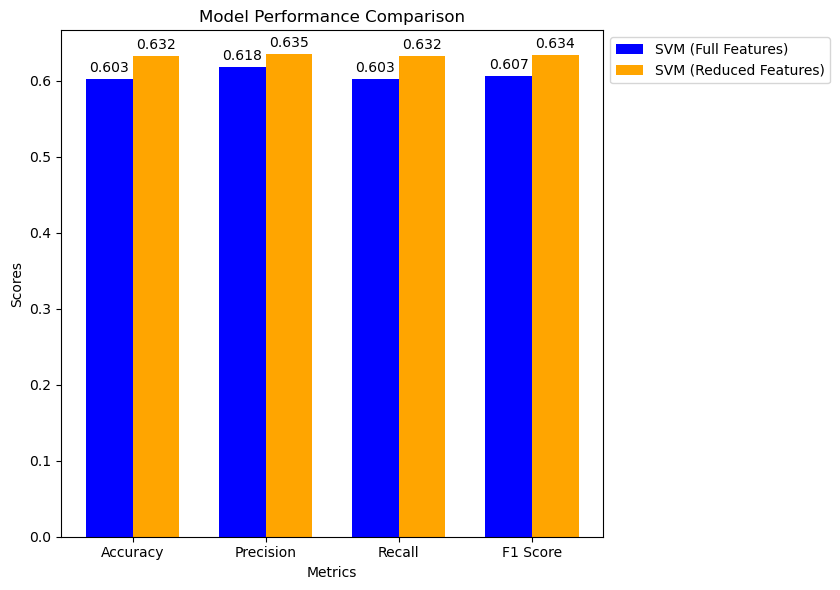

In [30]:
# Plotting
# Model Performance Comparison Data
results = {
    "SVM (Full Features)": {
        'Accuracy': 0.6025,
        'Precision': 0.617760,
        'Recall': 0.6025,
        'F1 Score': 0.606543
    },
    "SVM (Reduced Features)": {
        'Accuracy': 0.6325,
        'Precision': 0.634858,
        'Recall': 0.6325,
        'F1 Score': 0.633559
    }
}

# Convert results to a DataFrame for easier plotting
results_df = pd.DataFrame(results).T

# Plotting
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
x = np.arange(len(metrics))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots(figsize=(10, 6))

# Plot bars for SVM (Full Features)
rects1 = ax.bar(x - width/2, results_df.loc['SVM (Full Features)', metrics], width, label='SVM (Full Features)', color='blue')

# Plot bars for SVM (Reduced Features)
rects2 = ax.bar(x + width/2, results_df.loc['SVM (Reduced Features)', metrics], width, label='SVM (Reduced Features)', color='orange')

# Add labels, title, and custom x-axis tick labels
ax.set_xlabel('Metrics')
ax.set_ylabel('Scores')
ax.set_title('Model Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(metrics)

# Move the legend outside the plot
ax.legend(loc='upper left', bbox_to_anchor=(1, 1))  # Place legend outside to the right

# Add value labels on top of the bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

# Adjust layout to make room for the legend
plt.tight_layout(rect=[0, 0, 0.85, 1])  # Adjust the right margin to fit the legend

# Show the plot
plt.show()